In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
FILE_NAME = r"data\2nd_acc_run_fucking_everything_yoloc.csv"

In [37]:
data = pd.read_csv(FILE_NAME)
data

,timestamp_s,Temp_180,Temp_181,Temp_182,Temp_183,Temp_332,Temp_333,Temp_056,Temp_057,Temp_058,...,Temp_053,VCU_INV_Torque_Cmd,INV_Motor_Speed,HVC_Err_BattFloating,HVC_Err_ModuleTimeout,HVC_Err_RefOverTemp,HVC_BMS_State,HVC_SDC_OK,HVC_IMD_OK,HVC_BMS_OK
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,24.1,24.1,24.1,24.1,24.4,24.3,24.3,24.4,24.3,...,24.2,NaN,0.0,b'TRUE',b'FALSE',b'FALSE',b'FALSE',b'TRUE',b'FALSE',b'TRUE'
3,3,24.1,24.1,24.1,24.1,24.4,24.3,24.3,24.4,24.3,...,24.2,NaN,0.0,b'TRUE',b'FALSE',b'FALSE',b'FALSE',b'TRUE',b'FALSE',b'TRUE'
4,4,24.1,24.1,24.1,24.1,24.4,24.3,24.3,24.4,24.3,...,24.2,NaN,0.0,b'TRUE',b'FALSE',b'FALSE',b'FALSE',b'TRUE',b'FALSE',b'TRUE'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4202,4202,28.2,28.2,27.9,28.3,27.1,27.1,26.3,26.4,26.4,...,26.3,0.0,0.0,b'FALSE',b'FALSE',b'FALSE',b'TRUE',b'TRUE',b'FALSE',b'FALSE'
4203,4203,28.2,28.2,27.9,28.3,27.1,27.1,26.3,26.4,26.4,...,26.3,0.0,0.0,b'FALSE',b'FALSE',b'FALSE',b'TRUE',b'TRUE',b'FALSE',b'FALSE'
4204,4204,28.2,28.2,27.9,28.3,27.1,27.1,26.3,26.4,26.4,...,26.3,0.0,0.0,b'FALSE',b'FALSE',b'FALSE',b'TRUE',b'TRUE',b'FALSE',b'FALSE'
4205,4205,28.2,28.2,27.9,28.3,27.1,27.1,26.3,26.4,26.4,...,26.3,0.0,0.0,b'FALSE',b'FALSE',b'FALSE',b'TRUE',b'TRUE',b'FALSE',b'FALSE'


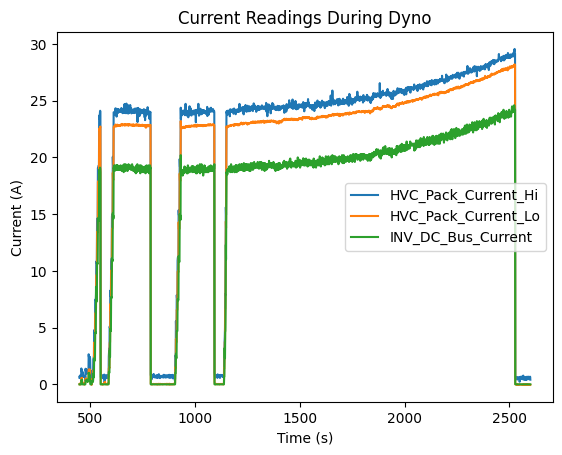

C:\Users\adisa\AppData\Local\Temp\ipykernel_23152\3551593901.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  time_filtered_data["Hi - Lo"] = time_filtered_data["HVC_Pack_Current_Hi"] - time_filtered_data["HVC_Pack_Current_Lo"]
C:\Users\adisa\AppData\Local\Temp\ipykernel_23152\3551593901.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  time_filtered_data["Inv - Lo"] = time_filtered_data["INV_DC_Bus_Current"] - time_filtered_data["HVC_Pack_Current_Lo"]


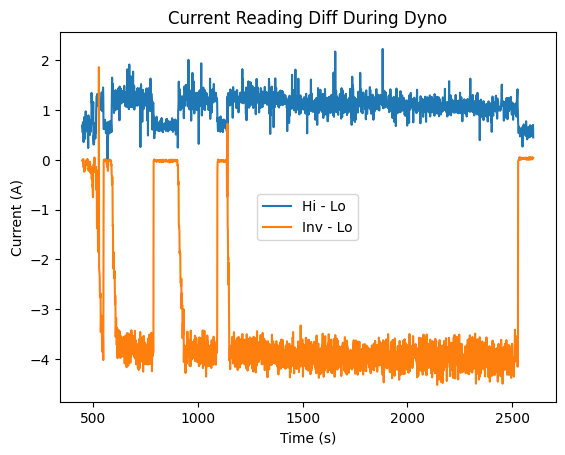

In [38]:
time_filtered_data = data[data["timestamp_s"].between(450, 2600)]

ax = time_filtered_data.plot(x = "timestamp_s", y = "HVC_Pack_Current_Hi")
ax = time_filtered_data.plot(x = "timestamp_s", y = "HVC_Pack_Current_Lo", ax=ax)
ax = time_filtered_data.plot(x = "timestamp_s", y = "INV_DC_Bus_Current", ax=ax)
ax.set_title("Current Readings During Dyno"), ax.set_xlabel("Time (s)"), ax.set_ylabel("Current (A)")
plt.show()

time_filtered_data["Hi - Lo"] = time_filtered_data["HVC_Pack_Current_Hi"] - time_filtered_data["HVC_Pack_Current_Lo"]
time_filtered_data["Inv - Lo"] = time_filtered_data["INV_DC_Bus_Current"] - time_filtered_data["HVC_Pack_Current_Lo"]
ax = time_filtered_data.plot(x = "timestamp_s", y = "Hi - Lo")
ax = time_filtered_data.plot(x = "timestamp_s", y = "Inv - Lo", ax=ax)
ax.set_title("Current Reading Diff During Dyno"), ax.set_xlabel("Time (s)"), ax.set_ylabel("Current (A)")
plt.show()

C:\Users\adisa\AppData\Local\Temp\ipykernel_23152\3076893013.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  time_filtered_data["Correct Final SOC"] = 18.5
C:\Users\adisa\AppData\Local\Temp\ipykernel_23152\3076893013.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  time_filtered_data["Capacity Adjusted SOC"] = 100 * ((max(time_filtered_data["HVC_SOC"])/100 * ADJ_CAP_As) - time_filtered_data["HVC_SOC_Delta_As"])/ADJ_CAP_As


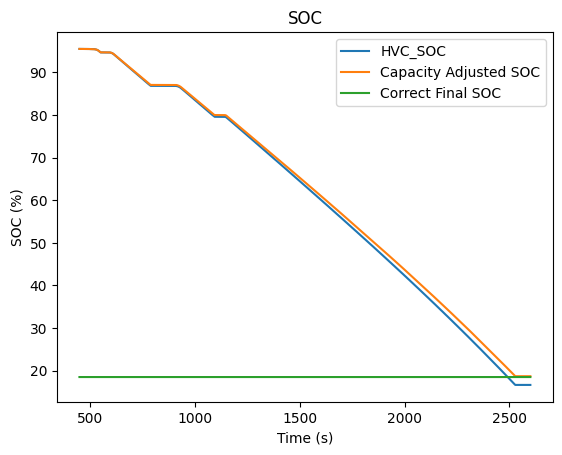

In [ ]:
ADJ_CAP_Ah = 15.4
ADJ_CAP_As = ADJ_CAP_Ah * 3600

time_filtered_data["Correct Final SOC"] = 18.5
time_filtered_data["Capacity Adjusted SOC"] = 100 * ((max(time_filtered_data["HVC_SOC"])/100 * ADJ_CAP_As) - time_filtered_data["HVC_SOC_Delta_As"])/ADJ_CAP_As

ax = time_filtered_data.plot(x = "timestamp_s", y = "HVC_SOC")
ax = time_filtered_data.plot(x = "timestamp_s", y = "Capacity Adjusted SOC", ax=ax)
ax = time_filtered_data.plot(x = "timestamp_s", y = "Correct Final SOC", ax=ax)
ax.set_title("SOC"), ax.set_xlabel("Time (s)"), ax.set_ylabel("SOC (%)")
plt.show()

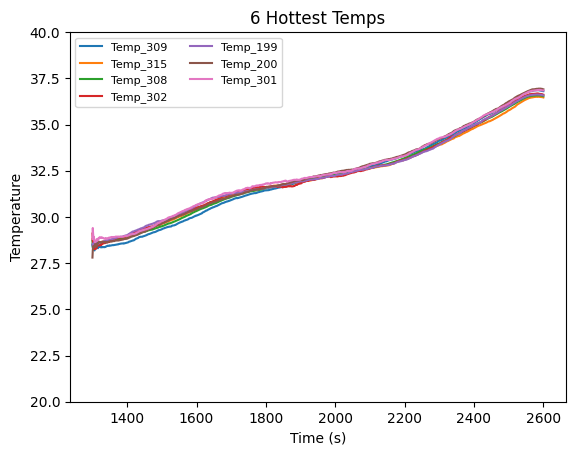

In [67]:
# Configurable moving average window (samples)
TEMP_MA_WINDOW = 100

time_filtered_data = time_filtered_data[time_filtered_data["timestamp_s"].between(1300, 2600)]

temp_cols = [col for col in time_filtered_data.columns if col.startswith("Temp_") and col != "Temp_082"]
if not temp_cols:
    raise ValueError("No Temp_ columns found in the CSV.")

temp_smoothed = time_filtered_data[temp_cols].rolling(window=TEMP_MA_WINDOW, min_periods=1).mean()

col_means = temp_smoothed.mean().sort_values()
hottest_cols = col_means.tail(7).index.tolist()

ax = temp_smoothed[hottest_cols].plot()
ax.set_ybound(20, 40)
ax.set_title("6 Hottest Temps")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Temperature")
ax.legend(ncol=2, fontsize=8)

plt.show()

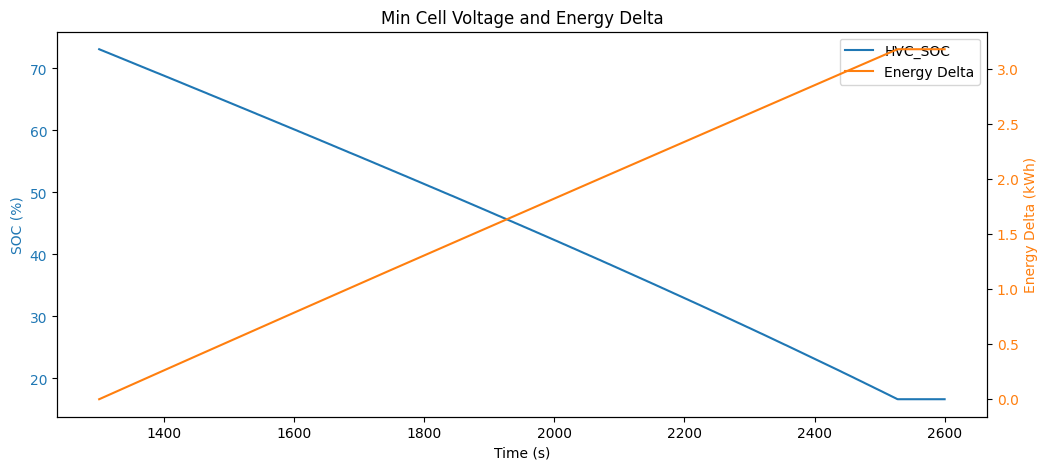

In [70]:
cell_voltage_cols = [col for col in time_filtered_data.columns if col.startswith("Cell_") and col.endswith("_Voltage")]
if not cell_voltage_cols:
    raise ValueError("No Cell_###_Voltage columns found in the CSV.")

# min_cell_voltage_mv = time_filtered_data[cell_voltage_cols].min(axis=1)
# min_cell_voltage_v = min_cell_voltage_mv / 1000.0
soc = time_filtered_data["HVC_SOC"]

power_w = time_filtered_data["HVC_Pack_Current_Lo"] * time_filtered_data["HVC_Pack_Voltage"]
dt_s = time_filtered_data["timestamp_s"].diff().fillna(0)
energy_ws = ((power_w.shift(1).fillna(power_w) + power_w) / 2.0) * dt_s
time_filtered_data["Energy_Delta_kWh"] = energy_ws.cumsum() / 3_600_000.0

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(time_filtered_data["timestamp_s"], soc, color="tab:blue", label="HVC_SOC")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("SOC (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(time_filtered_data["timestamp_s"], time_filtered_data["Energy_Delta_kWh"], color="tab:orange", label="Energy Delta")
ax2.set_ylabel("Energy Delta (kWh)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
ax1.set_title("Min Cell Voltage and Energy Delta")
plt.show()